# Statistical Customer Segmentation System

## Notebook 06: Cluster Evaluation and Business Insights

### Purpose

This notebook evaluates clustering performance and translates statistical findings into actionable customer insights.

### Objectives

- Evaluate cluster quality
- Assess customer segment characteristics
- Generate customer personas
- Develop business recommendations
- Create portfolio-ready visualizations

### Expected Outcome

A complete customer segmentation framework supported by statistical evidence and business interpretation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import os

os.makedirs("images", exist_ok=True)

In [2]:
rfm = pd.read_csv(
    "customer_segments.csv",
    index_col=0
)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,37,1,711.79,0
12348.0,27,1,892.80,0
12359.0,1,1,547.50,2
12370.0,27,2,1864.27,0
12377.0,24,1,1001.52,0


## Cluster Quality Evaluation

In [3]:
features = rfm[
    ["Recency","Frequency","Monetary"]
]

scaler = StandardScaler()

scaled = scaler.fit_transform(
    features
)

In [4]:
sil_score = silhouette_score(
    scaled,
    rfm["Cluster"]
)

print(
    "Silhouette Score:",
    round(sil_score,3)
)

Silhouette Score: 0.737


## Cluster Distribution

In [5]:
cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

,count
Cluster,
0,768
1,1
2,335


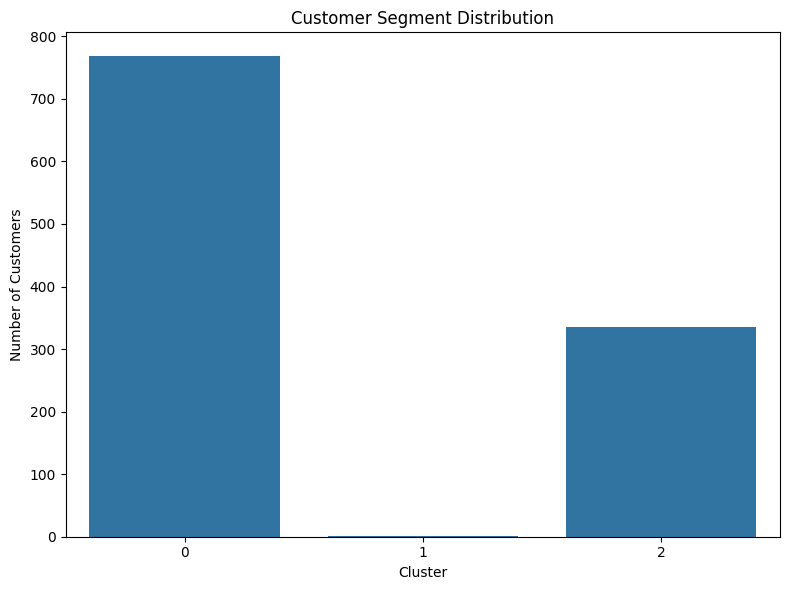

In [6]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title(
    "Customer Segment Distribution"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Number of Customers"
)

plt.tight_layout()

plt.savefig(
    "images/customer_segment_distribution.png",
    dpi=300
)

plt.show()

## Customer Segment Profiles

In [7]:
cluster_profile = (
    rfm.groupby("Cluster")
       [["Recency",
         "Frequency",
         "Monetary"]]
       .mean()
       .round(2)
)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,32.93,1.58,458.23
1,1.00,399.00,204223.96
2,4.59,2.79,1190.60


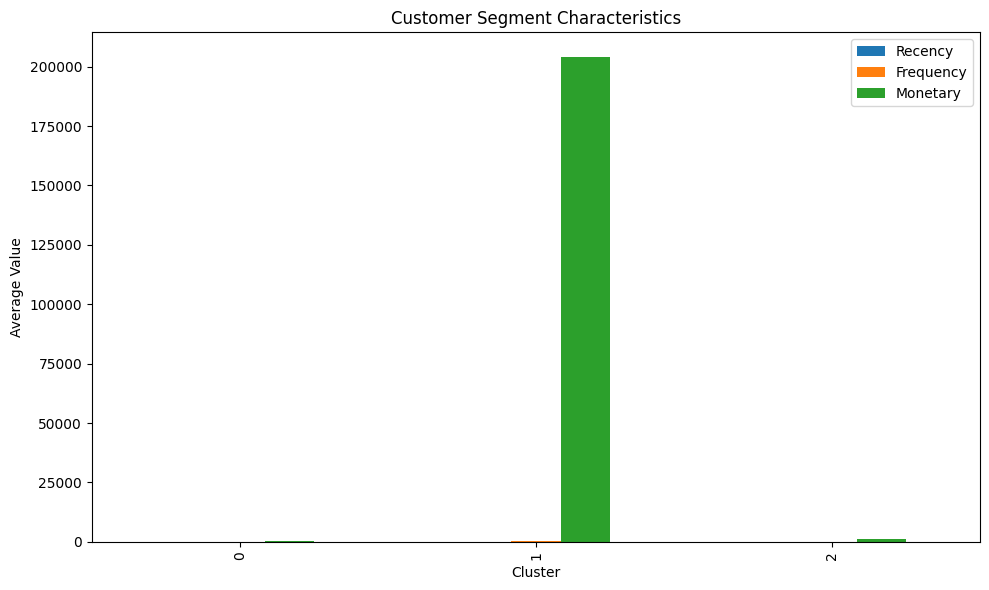

In [8]:
cluster_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Customer Segment Characteristics"
)

plt.ylabel(
    "Average Value"
)

plt.tight_layout()

plt.savefig(
    "images/customer_segment_profiles.png",
    dpi=300
)

plt.show()

## Revenue Contribution by Segment

In [9]:
segment_revenue = (
    rfm.groupby("Cluster")
       ["Monetary"]
       .sum()
       .round(2)
)

segment_revenue

,Monetary
Cluster,
0,351919.30
1,204223.96
2,398852.32


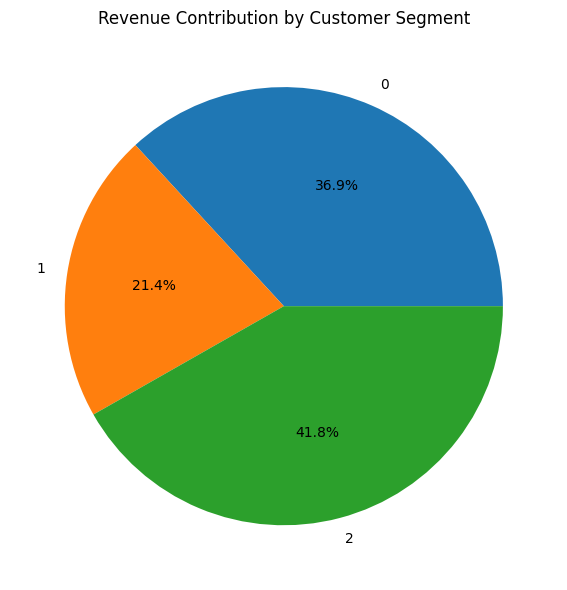

In [10]:
plt.figure(figsize=(8,6))

plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct="%1.1f%%"
)

plt.title(
    "Revenue Contribution by Customer Segment"
)

plt.tight_layout()

plt.savefig(
    "images/revenue_contribution.png",
    dpi=300
)

plt.show()

## Customer Personas

In [11]:
personas = pd.DataFrame(
{
"Segment":[
"Occasional Customers",
"Active Customers",
"High-Value Customers"
],

"Description":[
"Infrequent and low-spending customers",
"Regular and engaged customers",
"Small group generating substantial revenue"
]
}
)

personas

,Segment,Description
0,Occasional Customers,Infrequent and low-spending customers
1,Active Customers,Regular and engaged customers
2,High-Value Customers,Small group generating substantial revenue


## Strategic Recommendations

### Occasional Customers

- Re-engagement campaigns
- Promotional incentives
- Targeted email marketing

### Active Customers

- Loyalty programs
- Personalized offers
- Cross-selling opportunities

### High-Value Customers

- Premium services
- VIP programs
- Retention-focused engagement

These strategies align customer relationship management efforts with observed purchasing behavior.

In [12]:
summary = pd.DataFrame(
{
"Metric":[
"Customers",
"Clusters",
"Silhouette Score"
],

"Value":[
len(rfm),
3,
round(sil_score,3)
]
}
)

summary

,Metric,Value
0,Customers,1104.000
1,Clusters,3.000
2,Silhouette Score,0.737


In [13]:
summary.to_csv(
    "project_summary.csv",
    index=False
)

print(
    "Project summary saved."
)

Project summary saved.


## Final Findings

Customer segmentation successfully identified distinct customer groups characterized by differing levels of purchasing activity and spending behavior.

The analysis demonstrated that customer behavior can be effectively represented using RFM features and statistical learning techniques.

A small proportion of customers generated disproportionately large revenue, while the majority of customers exhibited infrequent purchasing behavior.

These findings support the use of customer segmentation for targeted marketing, customer retention, and revenue optimization.